In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import networkx as nx
import tifffile as tiff

from pyvis.network import Network

from plots import plot_feature_drugs,gen_pyvis_graph

In [8]:
#load files and append HH12,13 (saved separately due to long execution time)
stages = [3,4,5,6,7,8,9,10,11,12,13]
path = "results/skeleton/main_results/"

nodes_all_stages=pickle.load(open(f"{path}nodes_list_all_3_to_11.txt","rb"))
adj_all_stages=pickle.load(open(f"{path}adj_list_all_3_to_11.txt","rb"))

temp = pickle.load(open(f"{path}nodes_list_all_hh12.txt","rb"))
nodes_all_stages.append(temp[0])
temp = pickle.load(open(f"{path}nodes_list_all_hh13.txt","rb"))
nodes_all_stages.append(temp[0])


temp = pickle.load(open(f"{path}adj_list_all_hh12.txt","rb"))
adj_all_stages.append(temp[0])
temp = pickle.load(open(f"{path}adj_list_all_hh13.txt","rb"))
adj_all_stages.append(temp[0])




In [ ]:
def count_neighbours(adj,min=0,max=999):
    adj = adj[adj>0]
    neighbours = adj.count()
    neighbours = neighbours[neighbours>=min]
    neighbours = neighbours[neighbours<=max]
    return neighbours

In [ ]:
def return_neighbours(adj):
    adj = adj[adj>0]
    neighbours = adj.count()
    neighbours = pd.Series.value_counts(neighbours)
    return neighbours

In [ ]:
properties = ["Number of Nodes","Mean Edge Length","Mean Node Weight","Average Degree of Non-Isolated Nodes","Number of Basis Cycles","Number of Components","Average Clustering","Average Shortest Path","Number of Isolated Nodes","Number of Components, Excluding Isolated Nodes","Proportion of Isolated Nodes"]
max_n = 5
n_list = range(max_n)

#3d datastructure
multi_cols = pd.MultiIndex.from_product([stages, n_list], names=['Stage', 'n'])
df = pd.DataFrame(index=properties, columns=multi_cols)


#set up properties that can be calculated directly

n_node_weights = []
n_neighbours_dists = []
stage_index=0
for i in range(len(stages)):
    stage=stages[i]

    for n in range(len(nodes_all_stages[i])):
        print(f"Stage: {stage}, n: {n}")
        nodes = nodes_all_stages[i][n]
        adj = adj_all_stages[i][n]


        adj = pd.DataFrame(adj)
        nodes = pd.DataFrame(nodes)

        df.loc["Number of Nodes",(stage,n)] = len(nodes)
        df.loc["Mean Edge Length",(stage,n)] = adj.values[adj.values>0].mean()
        df.loc["Mean Node Weight",(stage,n)] = np.mean(nodes["weight"])
        df.loc["Average Degree of Non-Isolated Nodes",(stage,n)] = count_neighbours(adj,min=1).mean()
        df.loc["Number of Isolated Nodes",(stage,n)] = np.array([count_neighbours(adj,min=0,max=100)==0]).sum()


        G=gen_networkx_graph(nodes,adj)
        print(f"Network generation complete\n")


        largest_cc = max(nx.connected_components(G), key=len)
        G_comp = G.subgraph(largest_cc).copy()


        df.loc["Number of Basis Cycles",(stage,n)] = len(sorted(nx.cycle_basis(G)))
        df.loc["Number of Components",(stage,n)] = len(sorted(nx.connected_components(G)))
        df.loc["Average Clustering",(stage,n)] = nx.average_clustering(G)
        df.loc["Average Shortest Path",(stage,n)] = nx.average_shortest_path_length(G_comp, weight='weight') #average shortest path of the largest component


        df.loc["Number of Components, Excluding Isolated Nodes",(stage,n)] = df.loc["Number of Components",(stage,n)] - df.loc["Number of Isolated Nodes",(stage,n)]
        df.loc["Proportion of Isolated Nodes", (stage,n)] = df.loc["Number of Isolated Nodes",(stage,n)] / df.loc["Number of Nodes",(stage,n)]

        xmin = nodes["x"].quantile(0.01)
        xmax = nodes["x"].quantile(0.99)
        df.loc["Mean Edge Length, Standardised",(stage,n)] = df.loc["Mean Edge Length",(stage,n)]/ (4*(xmax-xmin))


  


Stage: 3, n: 0
Network generation complete

Stage: 3, n: 1
Network generation complete

Stage: 4, n: 0
Network generation complete

Stage: 4, n: 1
Network generation complete

Stage: 4, n: 2
Network generation complete

Stage: 4, n: 3
Network generation complete

Stage: 5, n: 0
Network generation complete

Stage: 5, n: 1
Network generation complete

Stage: 6, n: 0
Network generation complete

Stage: 6, n: 1
Network generation complete

Stage: 6, n: 2
Network generation complete

Stage: 7, n: 0
Network generation complete

Stage: 7, n: 1
Network generation complete

Stage: 8, n: 0
Network generation complete

Stage: 8, n: 1
Network generation complete

Stage: 9, n: 0
Network generation complete

Stage: 9, n: 1
Network generation complete

Stage: 9, n: 2
Network generation complete

Stage: 9, n: 3
Network generation complete

Stage: 9, n: 4
Network generation complete

Stage: 10, n: 0
Network generation complete

Stage: 10, n: 1
Network generation complete

Stage: 10, n: 2
Network genera

In [ ]:
for i in range(len(stages)):
    stage=stages[i]

    for n in range(len(nodes_all_stages[i])):
        print(f"Stage: {stage}, n: {n}")
        nodes = nodes_all_stages[i][n]
        adj = adj_all_stages[i][n]


        adj = pd.DataFrame(adj)
        nodes = pd.DataFrame(nodes)


        xmin = nodes["x"].quantile(0.01)
        xmax = nodes["x"].quantile(0.99)

        print(xmin,xmax)

        df.loc["Mean Edge Length, Standardised",(stage,n)] = df.loc["Mean Edge Length",(stage,n)]/ (4*(xmax-xmin))

Stage: 3, n: 0
362.2 1180.08
Stage: 3, n: 1
259.02 414.84
Stage: 4, n: 0
308.5 1006.4000000000001
Stage: 4, n: 1
443.12 1421.3600000000001
Stage: 4, n: 2
693.72 1359.76
Stage: 4, n: 3
100.55 1139.8
Stage: 5, n: 0
375.25 1216.15
Stage: 5, n: 1
354.95 1084.0
Stage: 6, n: 0
122.07000000000001 1248.0
Stage: 6, n: 1
808.1 1867.18
Stage: 6, n: 2
530.76 1664.3600000000001
Stage: 7, n: 0
461.68 1297.24
Stage: 7, n: 1
385.85 1548.45
Stage: 8, n: 0
241.61 1324.78
Stage: 8, n: 1
82.34 1093.6599999999999
Stage: 9, n: 0
188.07 1707.2399999999998
Stage: 9, n: 1
123.38 1385.08
Stage: 9, n: 2
105.76 1279.4299999999998
Stage: 9, n: 3
931.0 2274.86
Stage: 9, n: 4
745.26 2226.2200000000003
Stage: 10, n: 0
204.83 1661.9499999999998
Stage: 10, n: 1
239.0 1547.04
Stage: 10, n: 2
390.62 2109.2799999999997
Stage: 11, n: 0
94.0 1976.3899999999999
Stage: 11, n: 1
9.26 1533.0
Stage: 12, n: 0
14.0 1558.73
Stage: 12, n: 1
544.0 3224.0
Stage: 13, n: 0
303.22 2862.3399999999992
Stage: 13, n: 1
756.83 3250.17


In [21]:
def plot_feature(feature,df,stages,title):
    # get the specific feature and drop any missing embryos (the nans)
    prop_data = df.loc[feature].dropna()

    # prop_data is now a Series. 
    # The index contains your (Stage, n) pairs.
    # The values contain your actual numbers.

    stages_n = prop_data.index.get_level_values('Stage') # Grabs just the Stage numbers for each n
    values = prop_data.values                          # Grabs the actual data points
    means = mean_line(feature,df,stages)

    plt.figure(figsize=(8, 5))
    plt.scatter(stages_n, values, alpha=0.7, edgecolors='black')
    plt.plot(stages,means,linewidth=3)

    plt.xlabel("HH Stage")
    plt.xticks(stages) # Ensures your X-axis only shows the actual stage numbers
    if feature== "Mean Edge Length":
        plt.ylabel(f"{feature} in $\\mu m$")
        plt.ylim(bottom=0)
    else:
        plt.ylabel(feature)
    if title!="":
        plt.title(f"{title} Per Embryo")
        plt.savefig(f'results/skeleton/main_figs_svgs/{title}.svg', transparent=True, dpi=300)
    else:
        plt.title(f"{feature} Per Embryo")
        plt.savefig(f'results/skeleton/main_figs_svgs/{feature}.svg', transparent=True, dpi=300)
    
    
    plt.show()

   

In [ ]:
pickle.dump(df,open(f"results/skeleton/df_features_all_n.txt","wb"))

In [4]:
df = pickle.load(open(f"results/skeleton/main_results/df_features_all_n.txt","rb"))

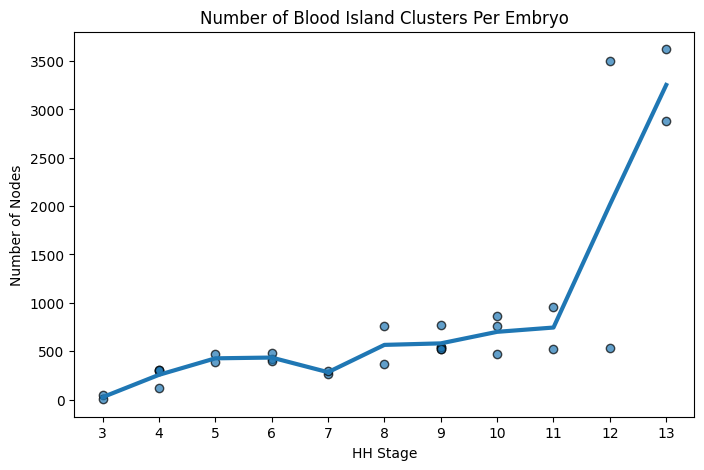

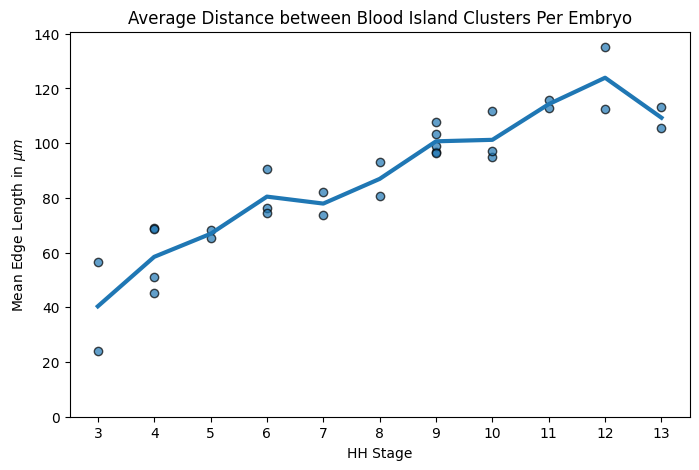

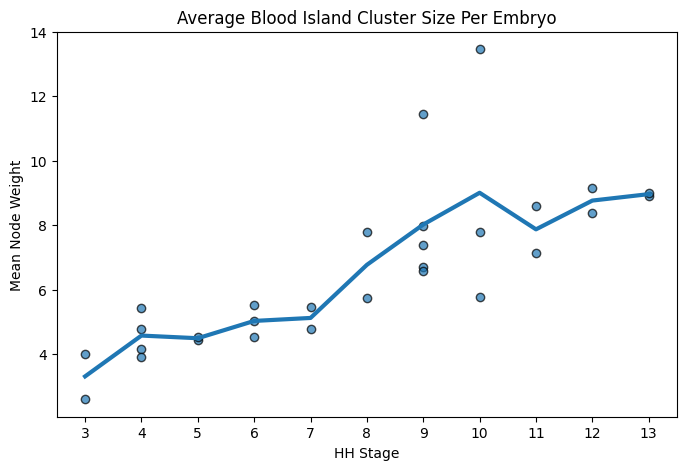

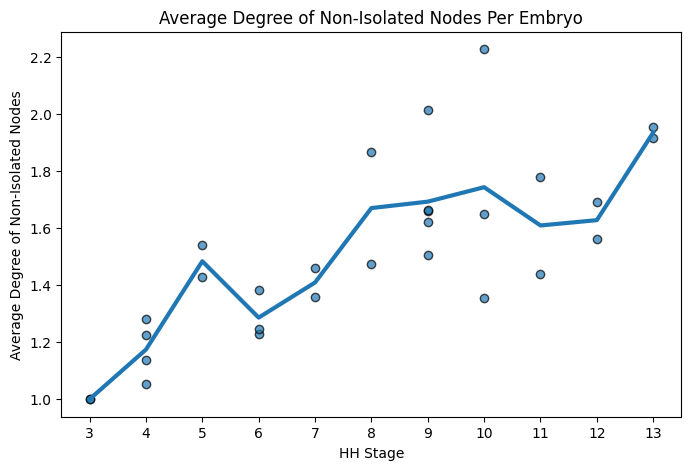

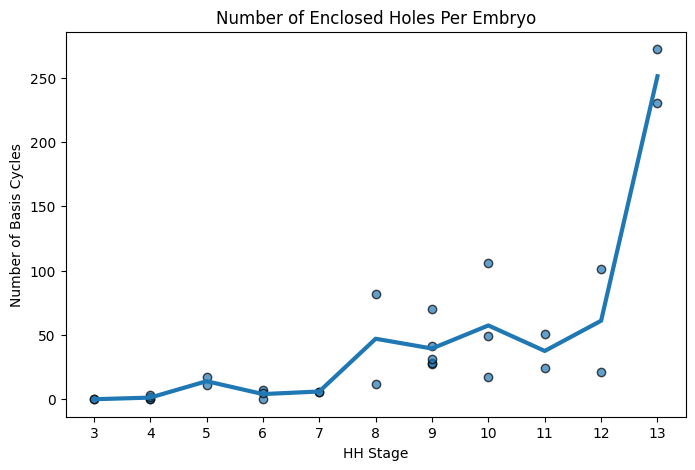

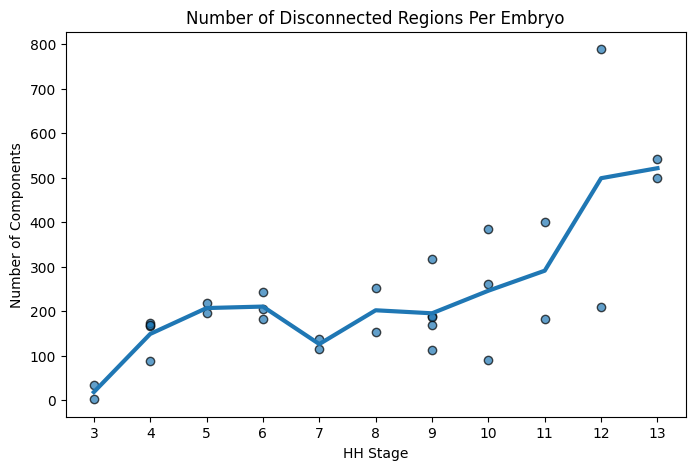

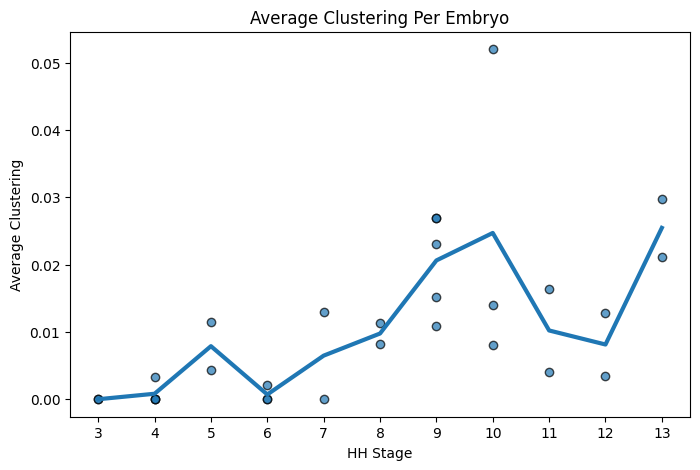

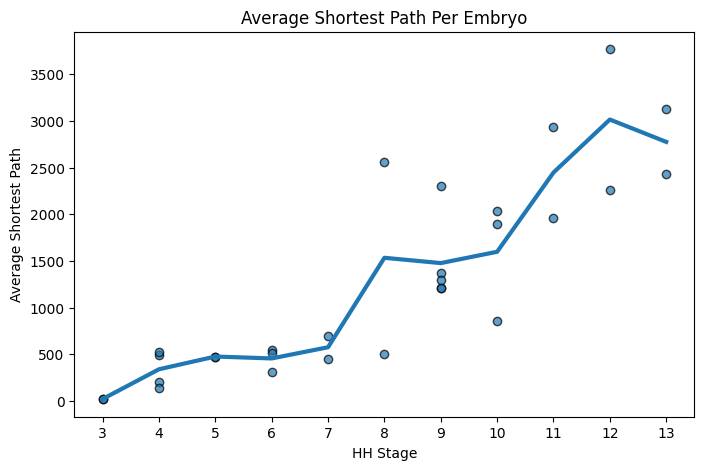

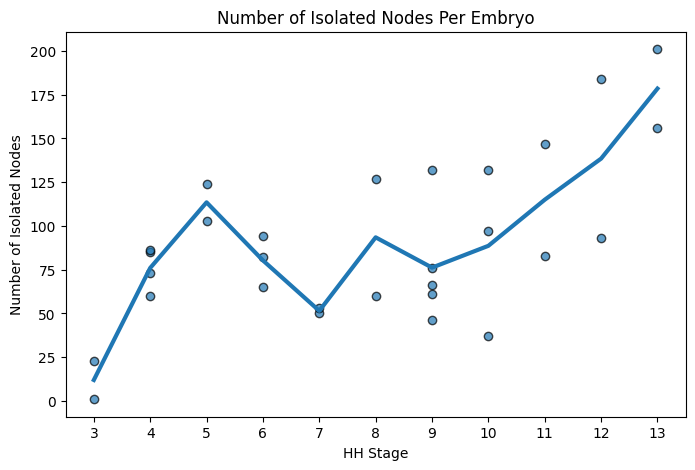

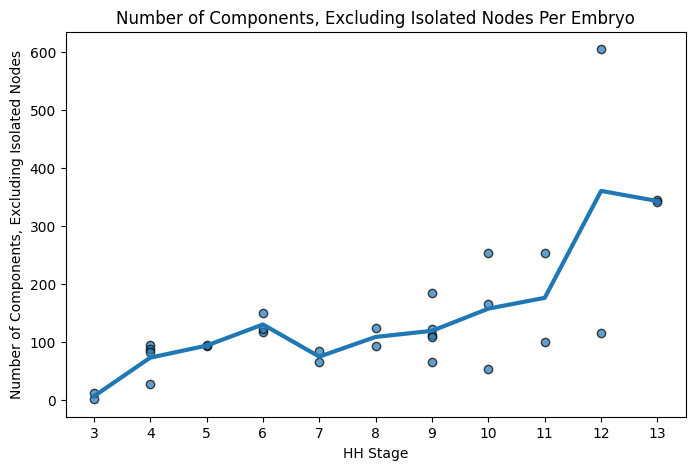

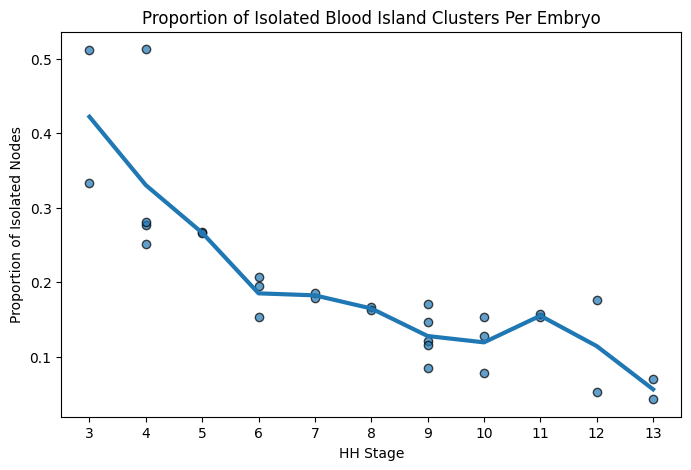

KeyError: 'Mean Edge Length, Standardised'

In [22]:
properties = ["Number of Nodes","Mean Edge Length","Mean Node Weight","Average Degree of Non-Isolated Nodes","Number of Basis Cycles","Number of Components","Average Clustering","Average Shortest Path","Number of Isolated Nodes","Number of Components, Excluding Isolated Nodes","Proportion of Isolated Nodes","Mean Edge Length, Standardised"]
titles = ["Number of Blood Island Clusters","Average Distance between Blood Island Clusters",
          "Average Blood Island Cluster Size","", 
          "Number of Enclosed Holes","Number of Disconnected Regions","",
          "","","","Proportion of Isolated Blood Island Clusters",""]
for i in range(len(properties)):
    property = properties[i]
    title = titles[i]
    plot_feature(property,df,stages,title)
    

In [15]:
pickle.dump(df,open(f"results/skeleton/df_features_all_n.txt","wb"))

In [5]:
def calc_degrees(adj,nodes):
    neighbours = adj.count()
    nodes["degree"] = neighbours
    return nodes

In [6]:
def calc_dists(adj,nodes):
    dists = adj.mean()
    nodes["distances"] = dists
    return nodes

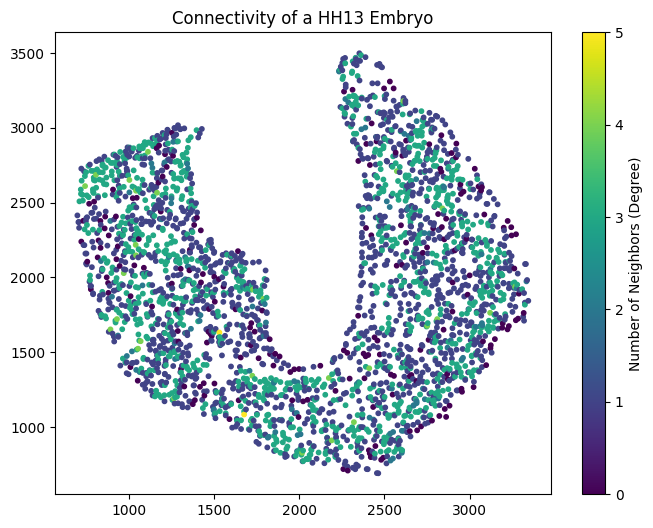

In [12]:
#specify input image
stage=13
stage_id = stages.index(stage)
n=2

path = f"data/skeleton/all/"  
image = tiff.imread(f'{path}n{n}_hh{stage}_skeleton.tif')
height = len(image)
width = len(image[0])
nodes = nodes_all_stages[stage_id][n-1]
adj = adj_all_stages[stage_id][n-1]

#append the degree data
nodes = calc_degrees(adj,nodes)


plt.figure(figsize=(8, 6))
# c='degree' maps the color to the feature, cmap is the color scheme
scatter = plt.scatter(nodes['x'], height-nodes['y'], c=nodes['degree'], cmap='viridis', s=10)
plt.colorbar(scatter, label='Number of Neighbors (Degree)')
plt.title(f'Connectivity of a HH{stage} Embryo')
plt.show()

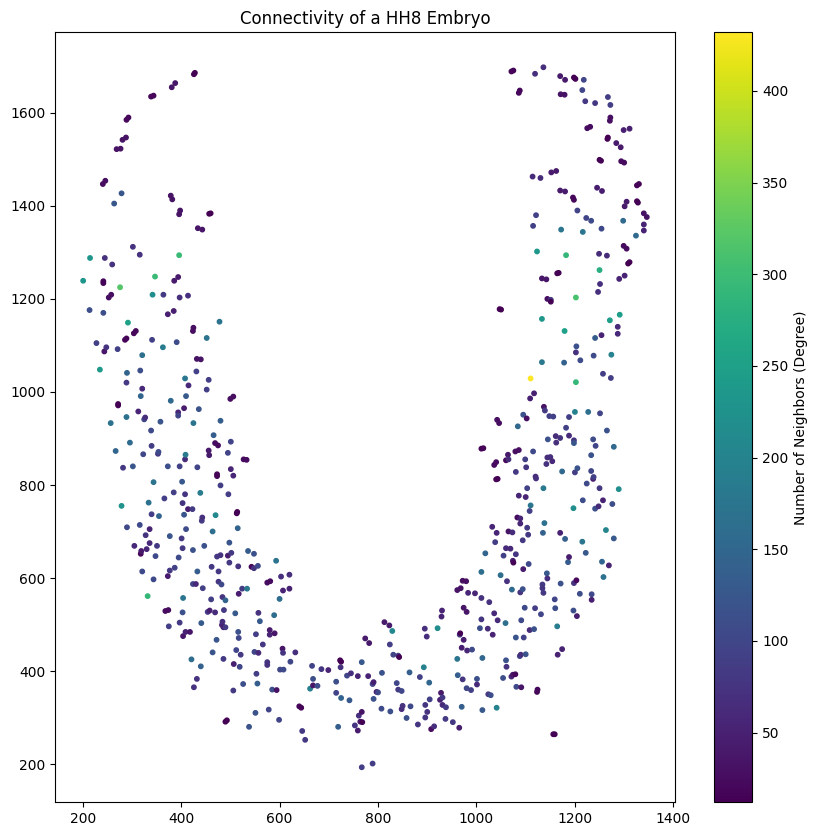

In [17]:
#specify input image
stages = [3,4,5,6,7,8,9,10,11,12,13]
stage=8
stage_id = stages.index(stage)
n=1

path = f"data/skeleton/all/"  
image = cv2.imread(f'{path}n{n}_hh{stage}_plain_scaled.jpg')
height = len(image)
width = len(image[0])
nodes = nodes_all_stages[stage_id][n-1]
adj = adj_all_stages[stage_id][n-1]

#append the degree data
nodes = calc_dists(adj,nodes)




fig,ax=plt.subplots(figsize=(10,10))
# c='degree' maps the color to the feature, cmap is the color scheme
scatter = plt.scatter(nodes['x'], height-nodes['y'], c=nodes['distances'], cmap='viridis', s=10)
fig.colorbar(scatter, label='Number of Neighbors (Degree)')
#ax.imshow(image, cmap=plt.cm.gray)
ax.set_title(f'Connectivity of a HH{stage} Embryo')

plt.show()

In [ ]:
stage = 6
n = 0

stage_id = stages.index(stage)


nodes = nodes_all_stages[stage_id][n]
adj = adj_all_stages[stage_id][n]


gen_pyvis_graph(nodes,adj,f"results/skeleton/hh{stages[stage_id]}_skeletonisation.html")

Local cdn resources have problems on chrome/safari when used in jupyter-notebook. 
edge between 95 and 95


<class 'pyvis.network.Network'> |N|=424 |E|=249

: 